In [2]:
import numpy as np
import pandas as pd
import csv
import random
from sklearn.linear_model import LogisticRegression
import sys
import os

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
random.seed(0)
np.random.seed(0)

from utils import *

enc = 'utf-8'

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [5]:
YEAR = 2023

In [6]:
#class ratio must be [0,1]
#lower number means more aggressive spliting towards the higher classes

NUMBER_OF_CLASSES = 10
CLASS_RATIO = 0.55

In [7]:
base_path = f'../../data/{NUTS2}/results/'

In [8]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_CMacedonia_Results_2010-2022.csv',
 'GR_CMacedonia_Results_2023-July-1st.csv',
 'GR_CMacedonia_Results_2023-July-2nd.csv',
 'GR_CMacedonia_Results_2023-June-1st.csv',
 'GR_CMacedonia_Results_2023-June-2nd.csv',
 'GR_CMacedonia_Results_2023-May-1st.csv',
 'GR_CMacedonia_Results_2023-May-2nd.csv']

In [9]:
file = file_list[0]

data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
data.drop(columns=['x', 'y', 'case'], inplace=True)
data.rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)


In [10]:
data

,lau1,day,month,year,score
0,θεσσαλονικης,16,8,2021,9.894434e-01
1,αλεξανδρειας,16,8,2021,9.887726e-01
2,αλεξανδρειας,1,8,2021,9.885786e-01
3,δελτα,1,9,2012,9.863749e-01
4,αλεξανδρειας,1,9,2021,9.861289e-01
...,...,...,...,...,...
5923,διου ολυμπου,16,11,2010,7.424888e-06
5924,νεαπολης συκεων,16,11,2010,6.447226e-06
5925,κασσανδρας,16,11,2010,3.871581e-06
5926,σιθωνιας,1,11,2010,2.347759e-06


In [11]:
data_og = data.copy()

In [12]:
np.sort(data.month.unique())

array([ 6,  7,  8,  9, 10, 11], dtype=int64)

In [13]:
np.sort(data.year.unique())

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022], dtype=int64)

In [14]:
zero_score = {'lau1': 'αγνωστη', 'day': 0, 'month': 0, 'year': 0, 'score': 0}
one_score = {'lau1': 'αγνωστη', 'day': 0, 'month': 0, 'year': 0, 'score': 1}

In [15]:
data = data.append(zero_score, ignore_index = True)
data = data.append(one_score, ignore_index = True)

In [16]:
data

,lau1,day,month,year,score
0,θεσσαλονικης,16,8,2021,9.894434e-01
1,αλεξανδρειας,16,8,2021,9.887726e-01
2,αλεξανδρειας,1,8,2021,9.885786e-01
3,δελτα,1,9,2012,9.863749e-01
4,αλεξανδρειας,1,9,2021,9.861289e-01
...,...,...,...,...,...
5925,κασσανδρας,16,11,2010,3.871581e-06
5926,σιθωνιας,1,11,2010,2.347759e-06
5927,σιθωνιας,16,11,2010,6.556912e-07
5928,αγνωστη,0,0,0,0.000000e+00


In [17]:
data_sorted = data.sort_values(by='score', ascending=True)

In [18]:
data_sorted.reset_index(drop = True, inplace = True)

In [19]:
data_sorted

,lau1,day,month,year,score
0,αγνωστη,0,0,0,0.000000e+00
1,σιθωνιας,16,11,2010,6.556912e-07
2,σιθωνιας,1,11,2010,2.347759e-06
3,κασσανδρας,16,11,2010,3.871581e-06
4,νεαπολης συκεων,16,11,2010,6.447226e-06
...,...,...,...,...,...
5925,δελτα,1,9,2012,9.863749e-01
5926,αλεξανδρειας,1,8,2021,9.885786e-01
5927,αλεξανδρειας,16,8,2021,9.887726e-01
5928,θεσσαλονικης,16,8,2021,9.894434e-01


<AxesSubplot:>

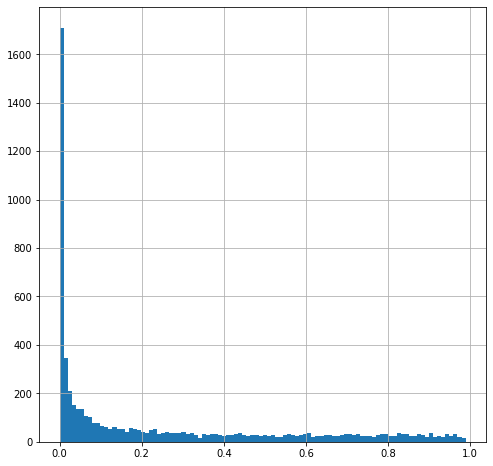

In [20]:
data_og.score.hist(bins = 100, figsize = (8,8))

In [21]:
number_of_observations = len(data_sorted)

In [22]:
r_sum = 0

for i in range(NUMBER_OF_CLASSES):
    r_sum = r_sum + CLASS_RATIO**i

x = round(number_of_observations/r_sum)

x

2675

In [23]:
temp_x = x
total_obs = 0
obs = []

for c in range(NUMBER_OF_CLASSES):
    total_obs = total_obs + temp_x
    obs.append(temp_x)
    print(f'Class {c}: {temp_x} observations')
    temp_x = round(temp_x*CLASS_RATIO)
    
print(f'\nTotal Observations: {total_obs}')

Class 0: 2675 observations
Class 1: 1471 observations
Class 2: 809 observations
Class 3: 445 observations
Class 4: 245 observations
Class 5: 135 observations
Class 6: 74 observations
Class 7: 41 observations
Class 8: 23 observations
Class 9: 13 observations

Total Observations: 5931


In [24]:
bins = []
sum = 0
for index in obs:
    sum = sum + index
    try:
        bin_lim = data_sorted.loc[sum, 'score']
    except KeyError:
        bin_lim = data_sorted.loc[number_of_observations-1, 'score']
    bins.append(bin_lim)

bins.insert(0,0)
bins[-1] = 1 

In [25]:
data_og['risk_class'] = pd.cut(data_og['score'], bins=bins, labels=False, include_lowest=True)

data_og.risk_class.value_counts().sort_index()

0    2675
1    1471
2     809
3     445
4     245
5     135
6      74
7      41
8      23
9      10
Name: risk_class, dtype: int64

In [26]:
bins_formatted = [ '%.4f' % elem for elem in bins]
print(bins_formatted)

['0.0000', '0.0584', '0.3421', '0.6302', '0.7928', '0.8781', '0.9285', '0.9569', '0.9693', '0.9819', '1.0000']


In [27]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_{YEAR}.csv'

with open(bins_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(bins)